# Bài làm thực thành kiểm tra giữa kì 

---

**Họ và tên:** Nguyễn Quang Linh
**MSSV:** 038205003016

---

### 1. Đọc dữ liệu vào bộ nhớ 

In [53]:
# Import thu vien pandas de xu ly du lieu
import pandas as pd

# Doc du lieu tu file CSV vao DataFrame
df = pd.read_csv('data/D6-Daily_Water_Intake.csv')

# Xem 5 dong dau tien cua du lieu
df.head()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor


### 2. Khám phá dữ liệu

#### a. Kích thước và chiều của dữ liệu

In [54]:
# =============================================================================
# a. KICH THUOC VA CHIEU CUA DU LIEU
# =============================================================================
# shape tra ve (so_dong, so_cot)
# ndim tra ve so chieu cua du lieu
print("=== a. KICH THUOC VA CHIEU CUA DU LIEU ===")
print(f"Kich thuoc (shape): {df.shape}")
print(f"  - So dong (thuc the): {df.shape[0]}")
print(f"  - So cot (thuoc tinh): {df.shape[1]}")
print(f"  - So chieu: {df.ndim}D")
print()


=== a. KICH THUOC VA CHIEU CUA DU LIEU ===
Kich thuoc (shape): (30000, 7)
  - So dong (thuc the): 30000
  - So cot (thuoc tinh): 7
  - So chieu: 2D



#### b. Kiểu dữ liệu của các thuộc tính

In [55]:
# =============================================================================
# b. KIEU DU LIEU CUA CAC THUOC TINH
# =============================================================================
print("=== b. KIEU DU LIEU CUA CAC THUOC TINH ===")
print(df.dtypes)

=== b. KIEU DU LIEU CUA CAC THUOC TINH ===
Age                              int64
Gender                          object
Weight (kg)                      int64
Daily Water Intake (liters)    float64
Physical Activity Level         object
Weather                         object
Hydration Level                 object
dtype: object


#### c. Số lượng thực thể của các giá trị nhãn

In [56]:
# =============================================================================
# c. SO LUONG THUC THE CUA CAC GIA TRI NHAN
# =============================================================================
print("=== c. SO LUONG THUC THE CUA CAC GIA TRI NHAN ===")
print("Cot nhan:'Hydration Level'")
print(df['Hydration Level'].value_counts())

=== c. SO LUONG THUC THE CUA CAC GIA TRI NHAN ===
Cot nhan:'Hydration Level'
Hydration Level
Good    23915
Poor     6085
Name: count, dtype: int64


#### d. Giá trị lớn nhất, bé nhất, và trung bình của các cột thuộc tính có giá trị số thực

In [57]:
# =============================================================================
# d. GIA TRI LON NHAT, NHO NHAT, TRUNG BINH CUA CAC COT SO
# =============================================================================
# select_dtypes chi lay cac cot co kieu so
print("=== d. GIA TRI MIN, MAX, MEAN CUA CAC COT SO ===")
# Lấy ra các thuộc tính kiểu numeric để có làm min Max
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(f"  Min: {df[col].min()}")
    print(f"  Max: {df[col].max()}")
    print(f"  Mean: {df[col].mean():.2f}")

=== d. GIA TRI MIN, MAX, MEAN CUA CAC COT SO ===

--- Age ---
  Min: 18
  Max: 69
  Mean: 43.47

--- Weight (kg) ---
  Min: 45
  Max: 109
  Mean: 76.85

--- Daily Water Intake (liters) ---
  Min: 1.5
  Max: 5.43
  Mean: 2.85


### 2. Tiền xử lý dữ liệu và trực quan hóa

#### a. Kiểm tra các thuộc tính của dữ liệu, xem xét bỏ những cột không có ý nghĩa dự đoán (như ID, tên,...). Giải thích tại sao các cột này cần xóa

In [58]:
print("=== KIEM TRA KIEU DU LIEU CUA CAC THUOC TINH ===")
print(df.dtypes)
# Lý giải
print(f"Em sẽ không loại bỏ dòng nào hết vì dòng nào cũng có ích cho việc dự báo  ")


=== KIEM TRA KIEU DU LIEU CUA CAC THUOC TINH ===
Age                              int64
Gender                          object
Weight (kg)                      int64
Daily Water Intake (liters)    float64
Physical Activity Level         object
Weather                         object
Hydration Level                 object
dtype: object
Em sẽ không loại bỏ dòng nào hết vì dòng nào cũng có ích cho việc dự báo  


#### b. Tìm giải pháp chuyển hết các thuộc  tính về dạng số. Mô tả rõ giải pháp làm.

In [59]:
# =============================================================================
# b. CHUYỂN ĐỔI THUỘC TÍNH VỀ DẠNG SỐ (LABEL ENCODER)
# =============================================================================
from sklearn.preprocessing import LabelEncoder

print("=== b. CHUYỂN ĐỔI DỮ LIỆU SANG SỐ ===")

# Danh sách các cột cần chuyển đổi
cols_to_encode = ['Physical Activity Level', 'Weather', 'Hydration Level', 'Gender']

# Áp dụng LabelEncoder
le = LabelEncoder()

for col in cols_to_encode:
    # .astype(str).str.strip(): Đảm bảo dữ liệu là chuỗi và xóa khoảng trắng thừa trước khi encode
    df[col] = le.fit_transform(df[col].astype(str).str.strip())

# Hiển thị kết quả
print("--- 5 dòng đầu sau khi chuyển đổi ---")
print(df.head())

print("\n--- Kiểm tra kiểu dữ liệu (Dtypes) ---")
print(df[cols_to_encode].dtypes)

=== b. CHUYỂN ĐỔI DỮ LIỆU SANG SỐ ===
--- 5 dòng đầu sau khi chuyển đổi ---
   Age  Gender  Weight (kg)  Daily Water Intake (liters)  \
0   56       1           96                         4.23   
1   60       1          105                         3.95   
2   36       1           68                         2.39   
3   19       0           74                         3.13   
4   38       1           77                         2.11   

   Physical Activity Level  Weather  Hydration Level  
0                        2        1                0  
1                        0        2                0  
2                        2        0                0  
3                        2        1                0  
4                        1        2                1  

--- Kiểm tra kiểu dữ liệu (Dtypes) ---
Physical Activity Level    int64
Weather                    int64
Hydration Level            int64
Gender                     int64
dtype: object


#### c. Thu giảm số chiều và hiển thị trên không gian 2D, các nhãn khác nhau cho các màu khác nhau.  Lưu ý cột nhãn là cột cuối cùng trong tập dữ liệu.

=== c. PCA & VISUALIZATION 2D ===

Phương sai giải thích bởi 2 thành phần chính: 45.38%


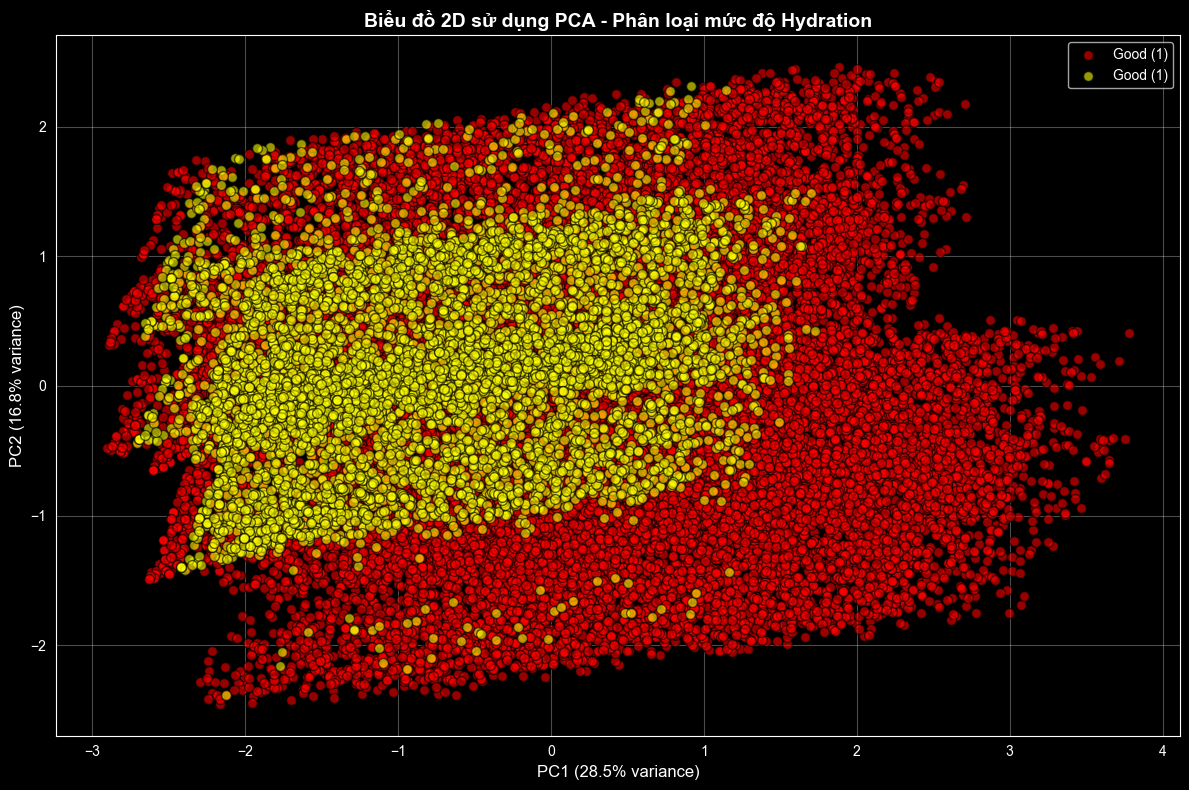


✓ Đã hoàn thành việc thu giảm số chiều và hiển thị 2D


In [60]:
# =============================================================================
# c. THU GIẢM SỐ CHIỀU (PCA)
# =============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("=== c. PCA & VISUALIZATION 2D ===")

# 1. Tách Features và Label (cột cuối cùng là nhãn)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
# 3. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Áp dụng PCA để giảm về 2 chiều
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

print(f"\nPhương sai giải thích bởi 2 thành phần chính: {pca.explained_variance_ratio_.sum():.2%}")

# 5. Vẽ biểu đồ phân tán 2D với các nhãn khác màu
plt.figure(figsize=(12, 8))

# Lấy các nhãn unique và tạo màu cho từng nhãn
unique_labels = sorted(set(y))
colors = ['red', 'yellow']
label_name = 'Poor (0)' if label == 0 else 'Good (1)'

for label, color in zip(unique_labels, colors):
    mask = y == label
    plt.scatter(principal_components[mask, 0],
                principal_components[mask, 1],
                c=[color],
                label=label_name,
                alpha=0.6,
                edgecolor='k',
                s=50)

plt.title('Biểu đồ 2D sử dụng PCA - Phân loại mức độ Hydration', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Đã hoàn thành việc thu giảm số chiều và hiển thị 2D")


#### 3. Huấn luyện các mô hình học máy và so sánh đánh giá theo k-fold cross validation, với k=10.
 Chọn 3 mô hình để đánh giá trong các mô hình phân lớp sau: KNN, Random Forest, Naive Bayes,  AdaBoost, và SVM.
Tinh chỉnh tham số để các mô hình cho kết quả tốt nhất trước khi so sánh.
Trình bày bảng so sánh hiệu năng các mô hình với độ đo F-Score


In [61]:
# =============================================================================
# 3. HUẤN LUYỆN, TINH CHỈNH VÀ SO SÁNH MÔ HÌNH (10-FOLD CV)
# =============================================================================
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import pandas as pd

print("=== 3. TRAINING & EVALUATION (TUNED MODELS) ===")

# 1. Định nghĩa mô hình và lưới tham số để tinh chỉnh
models_params = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [None, 10, 20],
            'criterion': ['gini', 'entropy']
        }
    },
    'SVM': {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    }
}

results = []

# 2. Vòng lặp: Tinh chỉnh -> Đánh giá k-fold
for name, mp in models_params.items():
    print(f"--> Đang xử lý: {name}...")
    
    # Tinh chỉnh tham số (Grid Search)
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='f1', n_jobs=-1)
    clf.fit(X_scaled, y) # Dùng X_scaled từ bước trước
    
    best_model = clf.best_estimator_
    best_params = clf.best_params_
    
    # Đánh giá 10-fold Cross-Validation trên mô hình tốt nhất
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(best_model, X_scaled, y, cv=cv, scoring='f1_macro') # F1 Macro cho đa lớp hoặc imbalanced
    
    # Lưu kết quả
    results.append({
        'Model': name,
        'Best Params': best_params,
        'Mean F1-Score': scores.mean(),
        'Std Dev': scores.std()
    })

# 3. Trình bày bảng so sánh
results_df = pd.DataFrame(results).sort_values(by='Mean F1-Score', ascending=False)

print("\n=== BẢNG SO SÁNH HIỆU NĂNG (F1-SCORE) ===")
print(results_df[['Model', 'Mean F1-Score', 'Std Dev']])
print("\n--- Chi tiết tham số tốt nhất ---")
for index, row in results_df.iterrows():
    print(f"{row['Model']}: {row['Best Params']}")

=== 3. TRAINING & EVALUATION (TUNED MODELS) ===
--> Đang xử lý: Random Forest...
--> Đang xử lý: SVM...
--> Đang xử lý: KNN...

=== BẢNG SO SÁNH HIỆU NĂNG (F1-SCORE) ===
           Model  Mean F1-Score   Std Dev
1            SVM       0.997778  0.000615
0  Random Forest       0.986642  0.002358
2            KNN       0.963211  0.003771

--- Chi tiết tham số tốt nhất ---
SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Random Forest: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 100}
KNN: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}


#### 4. Loại trừ cột nhãn và thực hiện gom cụm với K-Means và DBSCAN. Dùng giá trị nhãn để đánh giá kết quả gom cụm của hai giải thuật trên.

In [62]:
# =============================================================================
# 4. GOM CỤM (CLUSTERING) VÀ ĐÁNH GIÁ BẰNG NHÃN THỰC TẾ
# =============================================================================
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import numpy as np

print("=== 4. CLUSTERING EVALUATION ===")

# --- 1. K-MEANS ---
# Số cụm k bằng số lượng nhãn thực tế (ở đây là 2: Poor/Good)
k = len(np.unique(y))
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

# --- 2. DBSCAN ---
# eps và min_samples cần tinh chỉnh tùy vào mật độ dữ liệu
# eps: Bán kính lân cận (Dữ liệu đã chuẩn hóa nên thử khoảng 0.5 - 2.0)
dbscan = DBSCAN(eps=1.5, min_samples=4)
db_labels = dbscan.fit_predict(X_scaled)

# --- 3. ĐÁNH GIÁ KẾT QUẢ ---
# Hàm in kết quả đánh giá
def evaluate_clustering(algo_name, true_labels, pred_labels):
    # Loại bỏ nhiễu (-1) của DBSCAN khi tính toán nếu cần, nhưng ở đây ta tính hết để thấy hiệu quả thực
    ari = adjusted_rand_score(true_labels, pred_labels)
    nmi = normalized_mutual_info_score(true_labels, pred_labels)

    print(f"--- {algo_name} ---")
    print(f"  Số cụm tìm được: {len(np.unique(pred_labels))}")
    if -1 in pred_labels:
        print(f"  Số điểm nhiễu (Noise): {list(pred_labels).count(-1)}")
    print(f"  Adjusted Rand Index (ARI): {ari:.4f} (Càng gần 1 càng tốt)")
    print(f"  Normalized Mutual Info (NMI): {nmi:.4f} (Càng gần 1 càng tốt)")
    print()

# In kết quả
evaluate_clustering("K-Means", y, km_labels)
evaluate_clustering("DBSCAN", y, db_labels)
# So sánh nhanh
print("-> Nhận xét: ARI và NMI đo lường độ tương đồng giữa phân cụm và nhãn thật.")

=== 4. CLUSTERING EVALUATION ===
--- K-Means ---
  Số cụm tìm được: 2
  Adjusted Rand Index (ARI): 0.0133 (Càng gần 1 càng tốt)
  Normalized Mutual Info (NMI): 0.0237 (Càng gần 1 càng tốt)

--- DBSCAN ---
  Số cụm tìm được: 2
  Adjusted Rand Index (ARI): -0.0000 (Càng gần 1 càng tốt)
  Normalized Mutual Info (NMI): 0.0000 (Càng gần 1 càng tốt)

-> Nhận xét: ARI và NMI đo lường độ tương đồng giữa phân cụm và nhãn thật.
